<a href="https://colab.research.google.com/github/ByvatovS/ML_Task/blob/main/Twitter_Sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
#!unzip archive.zip

The task of classifying comments into positive and negative.

In [6]:
import pandas as pd
import numpy as np
import re

In [7]:
train = pd.read_csv('twitter_training.csv')
valid = pd.read_csv('twitter_validation.csv')

In [8]:
train.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [9]:
train.shape

(74681, 4)

In [10]:
valid.head()

,3364,Facebook,Irrelevant,"I mentioned on Facebook that I was struggling for motivation to go for a run the other day, which has been translated by Tom’s great auntie as ‘Hayley can’t get out of bed’ and told to his grandma, who now thinks I’m a lazy, terrible person 🤣"
0,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
1,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
2,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
3,4433,Google,Neutral,Now the President is slapping Americans in the...
4,6273,FIFA,Negative,Hi @EAHelp I’ve had Madeleine McCann in my cel...


###Let's say we're going to solve the problem of classifying comments, regardless of which platform or game they were written on. We will also delete the column with the user id data.

In [11]:
train = train.drop(['Borderlands' , '2401'], axis = 1)
train = train.rename(columns = {'Positive': 'sentiment' , 'im getting on borderlands and i will murder you all ,' : 'comments'})

valid = valid.drop(['Facebook' , '3364'], axis = 1)
valid = valid.rename(columns = {'Irrelevant': 'sentiment' , 'I mentioned on Facebook that I was struggling for motivation to go for a run the other day, which has been translated by Tom’s great auntie as ‘Hayley can’t get out of bed’ and told to his grandma, who now thinks I’m a lazy, terrible person 🤣' : 'comments'})

train.head()

,sentiment,comments
0,Positive,I am coming to the borders and I will kill you...
1,Positive,im getting on borderlands and i will kill you ...
2,Positive,im coming on borderlands and i will murder you...
3,Positive,im getting on borderlands 2 and i will murder ...
4,Positive,im getting into borderlands and i can murder y...


###Let's check the dataset for omissions and duplicates.

In [12]:
train.isnull().sum()

,0
sentiment,0
comments,686


In [13]:
train = train.dropna()
train.isnull().sum()

,0
sentiment,0
comments,0


In [14]:
train.duplicated().sum()

4227

In [15]:
train = train.drop_duplicates()
train.duplicated().sum()

0

In [16]:
train.shape

(69768, 2)

# Text Preprocessing:
1. Lowercasing
2. Remove HTML tegs, links and emails
3. Remove punctuation
4. Remove Stop-words
5. Emoticon processing

In [17]:
train['comments'] = train['comments'].str.lower()
valid['comments'] = valid['comments'].str.lower()

train['comments'].head()

,comments
0,i am coming to the borders and i will kill you...
1,im getting on borderlands and i will kill you ...
2,im coming on borderlands and i will murder you...
3,im getting on borderlands 2 and i will murder ...
4,im getting into borderlands and i can murder y...


###Let's check if html tags are present.

In [18]:
html_pattern = re.compile('<.*?>')
ind_list = [ind for ind in train.index if bool(html_pattern.search(train['comments'][ind]))]
print(len(ind_list))

for i in ind_list[:8]: print(f"{i}: {train['comments'][i]}")

2273
40: <unk> gearbox really time to fix this 10 drops in the new borderlands 3 dlc or be fine to force bosses on mayhem 10 to get a legendary drop while everyone else i get 6-10 drops.. really needs alot
46: check<unk> this epic streamer!.
56: why does like<unk> man in borderlands have slicked back hair or you heard of bangs you stupid assholes
86: fuck yessssssss<unk>
130: do these new @ghostlifestyle<unk> they want drink ghost?.......
220: @borderlands something seems very broken with m10 drop rates. constantly dropping less gold from lower amounts here. how is this worked with your +2500% loot modifier on.<unk> swear i'm seeing more greens over blues than anything on boss kills.
244: <unk> 3 is good so far but guardian 2 will always be the fav
260: what a night! i had heeps of fun playing borderlands 2! we're getting closer and closer towards this end!!. through the stream we raided @clocksydraws! what a amazing streamer for beautiful art pieces! give it a follow if you don't alre

In [19]:
def remove_html(text):
    return html_pattern.sub('', text)
train.loc[ind_list, 'comments'] = train.loc[ind_list, 'comments'].apply(remove_html)
valid['comments'] = valid['comments'].apply(remove_html)

for i in ind_list[:8]: print(f"{i}: {train['comments'][i]}")

40:  gearbox really time to fix this 10 drops in the new borderlands 3 dlc or be fine to force bosses on mayhem 10 to get a legendary drop while everyone else i get 6-10 drops.. really needs alot
46: check this epic streamer!.
56: why does like man in borderlands have slicked back hair or you heard of bangs you stupid assholes
86: fuck yessssssss
130: do these new @ghostlifestyle they want drink ghost?.......
220: @borderlands something seems very broken with m10 drop rates. constantly dropping less gold from lower amounts here. how is this worked with your +2500% loot modifier on. swear i'm seeing more greens over blues than anything on boss kills.
244:  3 is good so far but guardian 2 will always be the fav
260: what a night! i had heeps of fun playing borderlands 2! we're getting closer and closer towards this end!!. through the stream we raided @clocksydraws! what a amazing streamer for beautiful art pieces! give it a follow if you don't already do!. goodnight!..


###Let's check for links

In [20]:
url_pattern = re.compile(r'https?://\S+|www\.\S+')
ind_list = [ind for ind in train.index if bool(url_pattern.search(train['comments'][ind]))]
print(len(ind_list))

for i in ind_list[:8]: print(f"{i}: {train['comments'][i]}")

1703
287: modern warfare for $38, borderlands 3 for $20, and more great game deals (ps4, xbox one, switch) unsorted.co/modern-warfare… https://t.co/2n68qojkhu
290: modern warfare not $38, borderlands for for $20, all more great game gear (ps4, xbox one, switch) unsorted.co/modern-warfare… https://t.co/2n68qojkhu]
291: modern warfare 11 for $ 38, borderlands 3 for $ 20, 200 and more great nintendo game group deals ( ps4, xbox one, nintendo switch ) also unsorted. see co / w modern - warfare database … https://t.co/2n68qojkhu ]
383: pretty happy with this! i made these sub badges for my friend @4eyegaming for his twitch! go check him out! he has started streaming borderlands 3 recently but he is a variety streamer! twitch.tv/4eyegaming .  https://t.co/borwkmszrs
533: we've been playing a lot of borderlands 2 on  . . also gotta love this stunning cosplay by kunaii cosplay! instagram.com/xxkunaiixx/ https://t.co/giwx2aqtuy
536: we've been playing a lot of borderlands 2 on .. also gotta sav

In [21]:
def remove_url(text):
    return url_pattern.sub('', text)
train.loc[ind_list, 'comments'] = train.loc[ind_list, 'comments'].apply(remove_url)
valid['comments'] = valid['comments'].apply(remove_url)

for i in ind_list[:8]: print(f"{i}: {train['comments'][i]}")

287: modern warfare for $38, borderlands 3 for $20, and more great game deals (ps4, xbox one, switch) unsorted.co/modern-warfare… 
290: modern warfare not $38, borderlands for for $20, all more great game gear (ps4, xbox one, switch) unsorted.co/modern-warfare… 
291: modern warfare 11 for $ 38, borderlands 3 for $ 20, 200 and more great nintendo game group deals ( ps4, xbox one, nintendo switch ) also unsorted. see co / w modern - warfare database …  ]
383: pretty happy with this! i made these sub badges for my friend @4eyegaming for his twitch! go check him out! he has started streaming borderlands 3 recently but he is a variety streamer! twitch.tv/4eyegaming .  
533: we've been playing a lot of borderlands 2 on  . . also gotta love this stunning cosplay by kunaii cosplay! instagram.com/xxkunaiixx/ 
536: we've been playing a lot of borderlands 2 on .. also gotta save this monkey cosplay on fox cosplay! instagram.com/xxkunaiixx/ 
537: we've been over playing a lot thinking of borderlan

###Let's try to remove all words containing a slash.

In [22]:
slash_pattern = re.compile(r'\b[^\s]*[\\/][^\s]*\b')
ind_list = [ind for ind in train.index if bool(slash_pattern.search(train['comments'][ind]))]
print(len(ind_list))

for i in ind_list[:8]: print(f"{i}: {train['comments'][i]}")

8812
5: so i spent a few hours making something for fun. . . if you don't know i am a huge @borderlands fan and maya is one of my favorite characters. so i decided to make myself a wallpaper for my pc. . here is the original image versus the creation i made :) enjoy! pic.twitter.com/mlsi5wf9jg
8: so i spent a few hours making something for fun. . . if you don't know i am a huge rhandlerr fan and maya is one of my favorite characters. so i decided to make myself a wallpaper for my pc. . here is the original image versus the creation i made :) enjoy! pic.twitter.com/mlsi5wf9jg
9: 2010 so i spent a few hours making something for fun. . . if you don't know i am a huge rhandlerr fan and maya is one of my favorite characters. so i decided to make myself a wallpaper for my pc. . here is the original image versus the creation i made :) enjoy! pic.twitter.com/mlsi5wf9jg
11: rock-hard la varlope, rare & powerful, handsome jackpot, borderlands 3 (xbox) dlvr.it/rmtrgf  
14: rock-hard la vita, rare

In [23]:
def remove_slash(text):
    return slash_pattern.sub('', text)
train.loc[ind_list, 'comments'] = train.loc[ind_list, 'comments'].apply(remove_slash)
valid['comments'] = valid['comments'].apply(remove_slash)

for i in ind_list[:8]: print(f"{i}: {train['comments'][i]}")

5: so i spent a few hours making something for fun. . . if you don't know i am a huge @borderlands fan and maya is one of my favorite characters. so i decided to make myself a wallpaper for my pc. . here is the original image versus the creation i made :) enjoy! 
8: so i spent a few hours making something for fun. . . if you don't know i am a huge rhandlerr fan and maya is one of my favorite characters. so i decided to make myself a wallpaper for my pc. . here is the original image versus the creation i made :) enjoy! 
9: 2010 so i spent a few hours making something for fun. . . if you don't know i am a huge rhandlerr fan and maya is one of my favorite characters. so i decided to make myself a wallpaper for my pc. . here is the original image versus the creation i made :) enjoy! 
11: rock-hard la varlope, rare & powerful, handsome jackpot, borderlands 3 (xbox)   
14: rock-hard la vita, rare but powerful, handsome jackpot, borderlands 1 (xbox) 
16: i-hard like me, rare london de, handso

###Now let's delete the words containing @.

In [24]:
pattern = re.compile(r'[^\s]*@[^\s]*')
ind_list = [ind for ind in train.index if bool(pattern.search(train['comments'][ind]))]
print(len(ind_list))

for i in ind_list[:8]: print(f"{i}: {train['comments'][i]}")

18202
5: so i spent a few hours making something for fun. . . if you don't know i am a huge @borderlands fan and maya is one of my favorite characters. so i decided to make myself a wallpaper for my pc. . here is the original image versus the creation i made :) enjoy! 
6: so i spent a couple of hours doing something for fun... if you don't know that i'm a huge @ borderlands fan and maya is one of my favorite characters, i decided to make a wallpaper for my pc.. here's the original picture compared to the creation i made:) have fun! pic.twitter.com / mlsi5wf9jg
7: so i spent a few hours doing something for fun... if you don't know i'm a huge @ borderlands fan and maya is one of my favorite characters.
29: we finished borderlands 3 finally yas! thank you for hanging out everyone! it was fun. i will try to stream tomorrow but if not i might so some irl streams while awayu. we shall see. thank you so much for the raids @mompou_mumpow @megamagwitch and @kfdmitch.
30: we finally finally find

In [25]:
def remove_(text):
    return pattern.sub('', text)
train.loc[ind_list, 'comments'] = train.loc[ind_list, 'comments'].apply(remove_)
valid['comments'] = valid['comments'].apply(remove_)

for i in ind_list[:8]: print(f"{i}: {train['comments'][i]}")

5: so i spent a few hours making something for fun. . . if you don't know i am a huge  fan and maya is one of my favorite characters. so i decided to make myself a wallpaper for my pc. . here is the original image versus the creation i made :) enjoy! 
6: so i spent a couple of hours doing something for fun... if you don't know that i'm a huge  borderlands fan and maya is one of my favorite characters, i decided to make a wallpaper for my pc.. here's the original picture compared to the creation i made:) have fun! pic.twitter.com / mlsi5wf9jg
7: so i spent a few hours doing something for fun... if you don't know i'm a huge  borderlands fan and maya is one of my favorite characters.
29: we finished borderlands 3 finally yas! thank you for hanging out everyone! it was fun. i will try to stream tomorrow but if not i might so some irl streams while awayu. we shall see. thank you so much for the raids   and 
30: we finally finally find borderlands 3 yes! thank you all for hanging out! it was

### Remove punctuation.
The characters "(", ")" will be processed separately, as they can act as a emojis.

In [26]:
import string
exclude = string.punctuation
exclude = exclude.replace('(','').replace(')','')
exclude

'!"#$%&\'*+,-./:;<=>?@[\\]^_`{|}~'

In [27]:
def remove_punc(text):
  return text.translate(str.maketrans('','',exclude))

print(train['comments'][30])
train['comments'] = train['comments'].apply(remove_punc)
valid['comments'] = valid['comments'].apply(remove_punc)
print(train['comments'][30])

we finally finally find borderlands 3 yes! thank you all for hanging out! it was fun. i'll try to stream tomorrow, but if not, maybe some irl streams. we'll see. thanks for the raids  mompou _ mumpow  megamagwitch and  kfdmitch.
we finally finally find borderlands 3 yes thank you all for hanging out it was fun ill try to stream tomorrow but if not maybe some irl streams well see thanks for the raids  mompou  mumpow  megamagwitch and  kfdmitch


In [28]:
def remove_bracket(text):
  indx_open = []
  indx_del = set()
  for ind ,chr in enumerate(text):
    if chr == '(':
      indx_open.append(ind)
    elif (chr == ')') and (len(indx_open) > 0):
      indx_del.add(ind)
      indx_del.add(indx_open.pop())

  return ''.join([chr for ind, chr in enumerate(text) if ind not in indx_del])

s = 'Its very() cool (really). Im thrilled)))()))('
print(remove_bracket(s))

Its very cool really. Im thrilled)))))(


In [29]:
train['comments'] = train['comments'].apply(remove_bracket)
valid['comments'] = valid['comments'].apply(remove_bracket)

### Remove Stop-words

In [30]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [31]:
def remove_stopwords(text):
    stop_words = set(stopwords.words('english'))
    new_text = [word for word in text.split() if word not in stop_words]

    return " ".join(new_text)

train['comments'] = train['comments'].apply(remove_stopwords)
valid['comments'] = valid['comments'].apply(remove_stopwords)

### Emoticon processing
We will delete all emojis that do not show emotions.

In [32]:
del_emoji_pattern=re.compile("["
                        u"\U0001F300-\U0001F5FF"  # Symbols & pictographs
                        u"\U0001F680-\U0001F6FF"  # Transport & map symbols
                        u"\U0001F700-\U0001F77F"  # Alchemical symbols
                        u"\U0001F780-\U0001F7FF"  # Geometric shapes
                        u"\U0001F800-\U0001F8FF"  # Supplemental arrows
                        u"\U0001FA00-\U0001FA6F"  # Chess symbols
                        u"\U0001FA70-\U0001FAFF"  # Symbols & pictographs
                        u"\U00002600-\U000026FF"  # Miscellaneous symbols
                        u"\U00002700-\U000027BF"  # Dingbats
                        u"\U000024C2-\U0001F251"  # Enclosed characters
                        u"\U0001F1E6-\U0001F1FF"  # Flags!
                        u"\U0001F3FB-\U0001F3FF"  # Skin tone modifiers
                          "]+",flags=re.UNICODE)

ind_list = [ind for ind in train.index if bool(del_emoji_pattern.search(train['comments'][ind]))]
print(len(ind_list))

for i in ind_list[:8]: print(f"{i}: {train['comments'][i]}")

26
9971: hype real 🪓
9974: hype 🪓
18211: imma need � stop racist
18457: ik � really expect lambotruck really want f5
19679: ill hop 10 games know train particular order overwatch halo 🪓god war horizon zero dawn assassins creed tomb raider star wars jedi fallen order gears war destiny world warcraft
19682: ill end 10 games know train particular order overwatch halo 🪓god war horizon 5 dawn assassins creed tomb raider star wars jedi second order gears war hearthstone world warcraft
19977: ( new ） content interesting easy enjoy news guides tips technical discussion wow shadowlands com wow publishing content creator youtube go com channel 1 ucj04y 1 …
23330: lag good … �


In [33]:
def remove_emoji(text):
  return del_emoji_pattern.sub('',text)
train.loc[ind_list , 'comments'] = train.loc[ind_list , 'comments'].apply(remove_emoji)
valid['comments'] = valid['comments'].apply(remove_emoji)

for i in ind_list[:8]: print(f"{i}: {train['comments'][i]}")

9971: hype real 
9974: hype 
18211: imma need  stop racist
18457: ik  really expect lambotruck really want f5
19679: ill hop 10 games know train particular order overwatch halo god war horizon zero dawn assassins creed tomb raider star wars jedi fallen order gears war destiny world warcraft
19682: ill end 10 games know train particular order overwatch halo god war horizon 5 dawn assassins creed tomb raider star wars jedi second order gears war hearthstone world warcraft
19977: ( new  content interesting easy enjoy news guides tips technical discussion wow shadowlands com wow publishing content creator youtube go com channel 1 ucj04y 1 …
23330: lag good … 


Emojis related to emotions we transform.

In [34]:
! pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 7.3 MB/s eta 0:00:00


In [35]:
import emoji
emoji_pattern=re.compile("["
                        u"\U0001F600-\U0001F64F"  # Emoticons+
                        u"\U0001F900-\U0001F9FF"  # Supplemental symbols & pictographs+
                          "]+",flags=re.UNICODE)
ind_list = [ind for ind in train.index if bool(emoji_pattern.search(train['comments'][ind]))]
print(len(ind_list))

for i in ind_list[:8]: print(f"{i}: {train['comments'][i]}")

788
575: top 4 favourite games say 🤔 sea thieves bioshock ssx3 battlefield 1
578: top 4 favourite games say 🤔 sea thieves … bioshock ssx3 battlefield 1 1 really
647: morning im split playing pso2 borderlands 3 todays stream 🤔 either way stream today happening im excited hang nonetheless hope weekend well 3
651: 1 morning im split playing pso2 borderlands 3 todays stream 🤔 either way stream today happening im excited hang nonetheless hope weekend well 3
671: h0rny friend also fantastic artist 🥰🥰🥰
707: borderlands fallout child would love game though terrific work 🤞
710: borderlands fallout child love company though terrific work 🤞
893: 🧨 burn babies 🧨


In [36]:
def replace_emoji(text):
    return re.sub(r"(:[^:]+:)", r" \1 ", emoji.demojize(text))

train.loc[ind_list , 'comments'] = train.loc[ind_list , 'comments'].apply(replace_emoji)
valid['comments'] = valid['comments'].apply(replace_emoji)

for i in ind_list[:8]: print(f"{i}: {train['comments'][i]}")

575: top 4 favourite games say  :thinking_face:  sea thieves bioshock ssx3 battlefield 1
578: top 4 favourite games say  :thinking_face:  sea thieves … bioshock ssx3 battlefield 1 1 really
647: morning im split playing pso2 borderlands 3 todays stream  :thinking_face:  either way stream today happening im excited hang nonetheless hope weekend well 3
651: 1 morning im split playing pso2 borderlands 3 todays stream  :thinking_face:  either way stream today happening im excited hang nonetheless hope weekend well 3
671: h0rny friend also fantastic artist  :smiling_face_with_hearts:  :smiling_face_with_hearts:  :smiling_face_with_hearts: 
707: borderlands fallout child would love game though terrific work  :crossed_fingers: 
710: borderlands fallout child love company though terrific work  :crossed_fingers: 
893:  :firecracker:  burn babies  :firecracker: 


In [37]:
train.duplicated().sum()

6612

In [38]:
train = train.drop_duplicates()
train.duplicated().sum()

0

In [39]:
train[train['comments'] == ""]

,sentiment,comments
10,Positive,
52,Neutral,
202,Negative,
388,Irrelevant,


In [40]:
train = train[train['comments'] != ""]
train[train['comments'] == ""]

,sentiment,comments


#Baseline: Random Forest using CountVectorizer

In [41]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [42]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize,sent_tokenize
from sklearn.feature_extraction.text import CountVectorizer

In [43]:
encoder = LabelEncoder()
train['sentiment'] = encoder.fit_transform(train['sentiment'])
valid['sentiment'] = encoder.transform(valid['sentiment'])

In [ ]:
X_train , y_train = train.iloc[:, 1:2] , train['sentiment']
X_valid , y_valid = valid.iloc[:, 1:2] , valid['sentiment']

X_valid , X_test, y_valid , y_test = train_test_split(X_valid, y_valid, test_size = 0.2 , random_state= 42)

In [ ]:
cv = CountVectorizer(ngram_range=(1 , 1) ,tokenizer= word_tokenize)
X_train_bow = cv.fit_transform(X_train['comments']).toarray()
X_valid_bow = cv.transform(X_valid['comments']).toarray()
X_test_bow = cv.transform(X_test['comments']).toarray()

In [44]:
def create_train_model(X_train, X_valid , y_train, y_valid, num_trees = 50):
  RFmodel = RandomForestClassifier(n_estimators=1, warm_start=True, n_jobs= -1 ,random_state=42)

  train_accuracies = []
  val_accuracies = []

  for num_tree in range(1, num_trees + 1):
      RFmodel.n_estimators = num_tree
      RFmodel.fit(X_train, y_train)

      y_train_pred = RFmodel.predict(X_train)
      y_val_pred = RFmodel.predict(X_valid)

      train_accuracy = accuracy_score(y_train, y_train_pred)
      val_accuracy = accuracy_score(y_valid, y_val_pred)

      train_accuracies.append(train_accuracy)
      val_accuracies.append(val_accuracy)

      print(f"Epoch {num_tree}/{num_trees} - Train Accuracy: {train_accuracy:.4f}, Val Accuracy: {val_accuracy:.4f}")

  return (train_accuracies , val_accuracies , RFmodel)

In [47]:
train_accuracies , val_accuracies , RFmodel = create_train_model(X_train_bow, X_valid_bow, y_train, y_valid, num_trees=30)

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Epoch 1/30 - Train Accuracy: 0.8896, Val Accuracy: 0.8761
Epoch 2/30 - Train Accuracy: 0.9029, Val Accuracy: 0.8824
Epoch 3/30 - Train Accuracy: 0.9615, Val Accuracy: 0.9312
Epoch 4/30 - Train Accuracy: 0.9739, Val Accuracy: 0.9487
Epoch 5/30 - Train Accuracy: 0.9836, Val Accuracy: 0.9449
Epoch 6/30 - Train Accuracy: 0.9881, Val Accuracy: 0.9512
Epoch 7/30 - Train Accuracy: 0.9906, Val Accuracy: 0.9537
Epoch 8/30 - Train Accuracy: 0.9920, Val Accuracy: 0.9549
Epoch 9/30 - Train Accuracy: 0.9931, Val Accuracy: 0.9524
Epoch 10/30 - Train Accuracy: 0.9936, Val Accuracy: 0.9574
Epoch 11/30 - Train Accuracy: 0.9942, Val Accuracy: 0.9587
Epoch 12/30 - Train Accuracy: 0.9946, Val Accuracy: 0.9574
Epoch 13/30 - Train Accuracy: 0.9950, Val Accuracy: 0.9599
Epoch 14/30 - Train Accuracy: 0.9950, Val Accuracy: 0.9574
Epoch 15/30 - Train Accuracy: 0.9953, Val Accuracy: 0.9574
Epoch 16/30 - Train Accuracy: 0.9954, Val Accuracy: 0.9574
Epoch 17/30 - Train Accuracy: 0.9955, Val Accuracy: 0.9574
Epoch 

In [45]:
def draw_story(train_accuracies ,val_accuracies ):
  num_trees = len(train_accuracies)
  plt.figure(figsize=(10, 6))
  plt.plot(range(1, num_trees + 1), train_accuracies, label='Train Accuracy', marker='o')
  plt.plot(range(1, num_trees + 1), val_accuracies, label='Validation Accuracy', marker='o')
  plt.xlabel('Number of Trees (Epochs)')
  plt.ylabel('Accuracy')
  plt.title('Accuracy vs Number of Trees')
  plt.legend()
  plt.grid()
  plt.show()

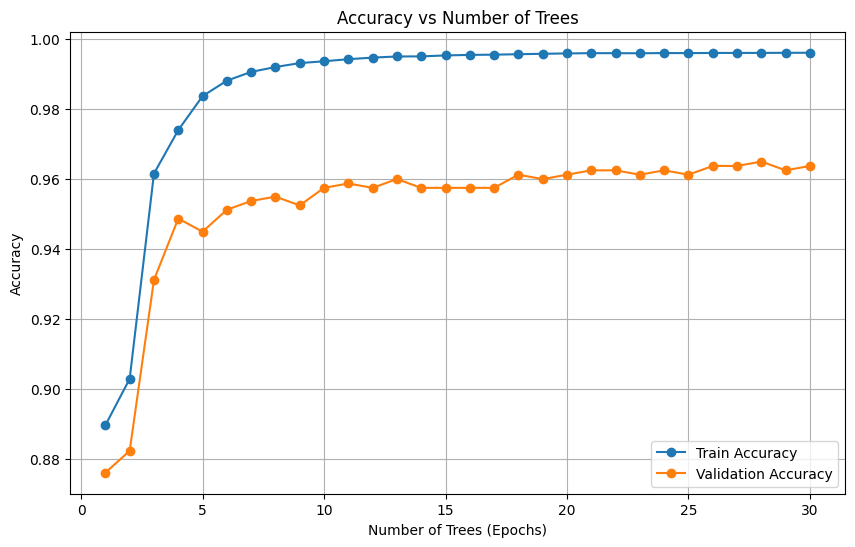

In [49]:
draw_story(train_accuracies ,val_accuracies )

In [46]:
def test_metrics(X_test ,y_test ,RFmodel):
  test_pred = RFmodel.predict(X_test)

  accuracy = accuracy_score(y_test, test_pred)
  precision = precision_score(y_test, test_pred, average='weighted')
  recall = recall_score(y_test,test_pred, average='weighted')
  f1 = f1_score(y_test,test_pred, average='weighted')


  print(f"Accuracy: {accuracy}")
  print(f"Precision: {precision}")
  print(f"Recall: {recall}")
  print(f"F1-Score: {f1}")

In [51]:
test_metrics(X_test_bow ,y_test ,RFmodel)

Accuracy: 0.975
Precision: 0.9751024723487314
Recall: 0.975
F1-Score: 0.9750073260073261


# Let's see if the results improve if we use lemmatization and stemming.

In [47]:
import spacy
nlp = spacy.load('en_core_web_sm')

In [48]:
train_lem , valid_lem = train.copy() , valid.copy()
for i in train.index[:8]: print(f"{i}: {train['comments'][i]}")

0: coming borders kill
1: im getting borderlands kill
2: im coming borderlands murder
3: im getting borderlands 2 murder
4: im getting borderlands murder
5: spent hours making something fun dont know huge fan maya one favorite characters decided make wallpaper pc original image versus creation made ) enjoy
6: spent couple hours something fun dont know im huge borderlands fan maya one favorite characters decided make wallpaper pc heres original picture compared creation made) fun pictwittercom mlsi5wf9jg
7: spent hours something fun dont know im huge borderlands fan maya one favorite characters


In [49]:
def lemmatization(text):
    doc = nlp(text)
    return " ".join([token.lemma_ for token in doc])

train_lem['comments'] = train_lem['comments'].apply(lemmatization)
valid_lem['comments'] = valid_lem['comments'].apply(lemmatization)

for i in train_lem.index[:8]: print(f"{i}: {train_lem['comments'][i]}")

0: come border kill
1: I m get borderland kill
2: I m come borderland murder
3: I m get borderland 2 murder
4: I m get borderland murder
5: spend hour make something fun do not know huge fan maya one favorite character decide make wallpaper pc original image versus creation make ) enjoy
6: spend couple hour something fun do not know I m huge borderland fan maya one favorite character decide make wallpaper pc here original picture compare creation make ) fun pictwittercom mlsi5wf9jg
7: spend hour something fun do not know I m huge borderland fan maya one favorite character


In [ ]:
X_train , y_train = train_lem.iloc[:, 1:2] , train_lem['sentiment']
X_valid , y_valid = valid_lem.iloc[:, 1:2] , valid_lem['sentiment']

X_valid , X_test, y_valid , y_test = train_test_split(X_valid, y_valid, test_size = 0.2 , random_state= 42)

In [ ]:
cv = CountVectorizer(ngram_range=(1 , 1) ,tokenizer= word_tokenize)
X_train_bow = cv.fit_transform(X_train['comments']).toarray()
X_valid_bow = cv.transform(X_valid['comments']).toarray()
X_test_bow = cv.transform(X_test['comments']).toarray()

In [55]:
train_accuracies , val_accuracies , RFmodel = create_train_model(X_train_bow, X_valid_bow, y_train, y_valid, num_trees=30)

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Epoch 1/30 - Train Accuracy: 0.8851, Val Accuracy: 0.8611
Epoch 2/30 - Train Accuracy: 0.8987, Val Accuracy: 0.8798
Epoch 3/30 - Train Accuracy: 0.9593, Val Accuracy: 0.9249
Epoch 4/30 - Train Accuracy: 0.9737, Val Accuracy: 0.9312
Epoch 5/30 - Train Accuracy: 0.9830, Val Accuracy: 0.9387
Epoch 6/30 - Train Accuracy: 0.9874, Val Accuracy: 0.9437
Epoch 7/30 - Train Accuracy: 0.9900, Val Accuracy: 0.9449
Epoch 8/30 - Train Accuracy: 0.9917, Val Accuracy: 0.9499
Epoch 9/30 - Train Accuracy: 0.9928, Val Accuracy: 0.9549
Epoch 10/30 - Train Accuracy: 0.9936, Val Accuracy: 0.9524
Epoch 11/30 - Train Accuracy: 0.9937, Val Accuracy: 0.9549
Epoch 12/30 - Train Accuracy: 0.9944, Val Accuracy: 0.9574
Epoch 13/30 - Train Accuracy: 0.9945, Val Accuracy: 0.9587
Epoch 14/30 - Train Accuracy: 0.9950, Val Accuracy: 0.9574
Epoch 15/30 - Train Accuracy: 0.9951, Val Accuracy: 0.9562
Epoch 16/30 - Train Accuracy: 0.9952, Val Accuracy: 0.9549
Epoch 17/30 - Train Accuracy: 0.9953, Val Accuracy: 0.9562
Epoch 

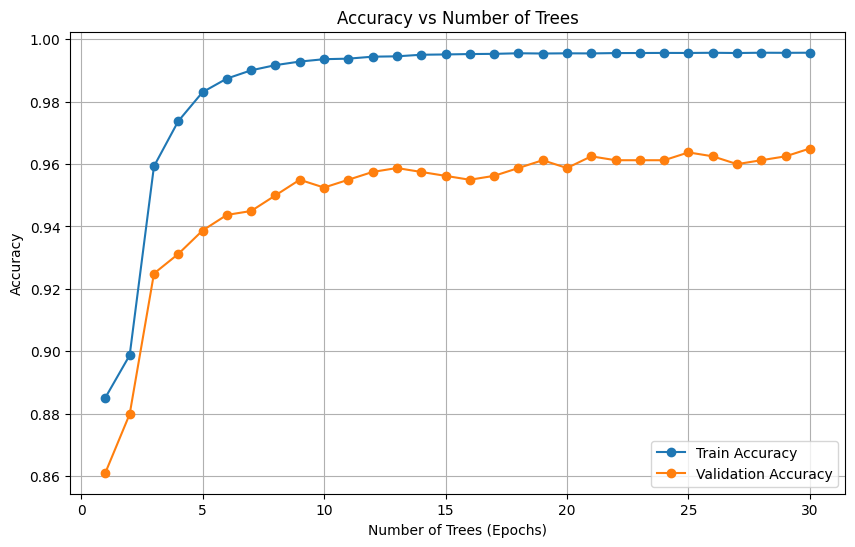

In [62]:
draw_story(train_accuracies ,val_accuracies)

In [63]:
test_metrics(X_test_bow ,y_test ,RFmodel)

Accuracy: 0.99
Precision: 0.9901315789473685
Recall: 0.99
F1-Score: 0.9900119658119658


##Stemming

In [64]:
from nltk.stem.porter import PorterStemmer

In [65]:
train_stem , valid_stem = train.copy() , valid.copy()
for i in train.index[:8]: print(f"{i}: {train['comments'][i]}")

0: coming borders kill
1: im getting borderlands kill
2: im coming borderlands murder
3: im getting borderlands 2 murder
4: im getting borderlands murder
5: spent hours making something fun dont know huge fan maya one favorite characters decided make wallpaper pc original image versus creation made ) enjoy
6: spent couple hours something fun dont know im huge borderlands fan maya one favorite characters decided make wallpaper pc heres original picture compared creation made) fun pictwittercom mlsi5wf9jg
7: spent hours something fun dont know im huge borderlands fan maya one favorite characters


In [66]:
ps=PorterStemmer()
def stemming(text):
    return " ".join([ps.stem(token) for token in text.split()])

train_stem['comments'] = train_stem['comments'].apply(stemming)
valid_stem['comments'] = valid_stem['comments'].apply(stemming)

for i in train_stem.index[:8]: print(f"{i}: {train_stem['comments'][i]}")

0: come border kill
1: im get borderland kill
2: im come borderland murder
3: im get borderland 2 murder
4: im get borderland murder
5: spent hour make someth fun dont know huge fan maya one favorit charact decid make wallpap pc origin imag versu creation made ) enjoy
6: spent coupl hour someth fun dont know im huge borderland fan maya one favorit charact decid make wallpap pc here origin pictur compar creation made) fun pictwittercom mlsi5wf9jg
7: spent hour someth fun dont know im huge borderland fan maya one favorit charact


In [ ]:
X_train , y_train = train_stem.iloc[:, 1:2] , train_stem['sentiment']
X_valid , y_valid = valid_stem.iloc[:, 1:2] , valid_stem['sentiment']

X_valid , X_test, y_valid , y_test = train_test_split(X_valid, y_valid, test_size = 0.2 , random_state= 42)

In [ ]:
cv = CountVectorizer(ngram_range=(1 , 1) ,tokenizer= word_tokenize)
X_train_bow = cv.fit_transform(X_train['comments']).toarray()
X_valid_bow = cv.transform(X_valid['comments']).toarray()
X_test_bow = cv.transform(X_test['comments']).toarray()

In [67]:
train_accuracies , val_accuracies , RFmodel = create_train_model(X_train_bow, X_valid_bow, y_train, y_valid, num_trees=30)

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Epoch 1/30 - Train Accuracy: 0.8925, Val Accuracy: 0.8561
Epoch 2/30 - Train Accuracy: 0.9045, Val Accuracy: 0.8686
Epoch 3/30 - Train Accuracy: 0.9616, Val Accuracy: 0.9099
Epoch 4/30 - Train Accuracy: 0.9752, Val Accuracy: 0.9274
Epoch 5/30 - Train Accuracy: 0.9841, Val Accuracy: 0.9362
Epoch 6/30 - Train Accuracy: 0.9877, Val Accuracy: 0.9462
Epoch 7/30 - Train Accuracy: 0.9907, Val Accuracy: 0.9524
Epoch 8/30 - Train Accuracy: 0.9920, Val Accuracy: 0.9537
Epoch 9/30 - Train Accuracy: 0.9932, Val Accuracy: 0.9512
Epoch 10/30 - Train Accuracy: 0.9937, Val Accuracy: 0.9574
Epoch 11/30 - Train Accuracy: 0.9940, Val Accuracy: 0.9587
Epoch 12/30 - Train Accuracy: 0.9945, Val Accuracy: 0.9625
Epoch 13/30 - Train Accuracy: 0.9946, Val Accuracy: 0.9562
Epoch 14/30 - Train Accuracy: 0.9949, Val Accuracy: 0.9574
Epoch 15/30 - Train Accuracy: 0.9950, Val Accuracy: 0.9587
Epoch 16/30 - Train Accuracy: 0.9951, Val Accuracy: 0.9587
Epoch 17/30 - Train Accuracy: 0.9951, Val Accuracy: 0.9625
Epoch 

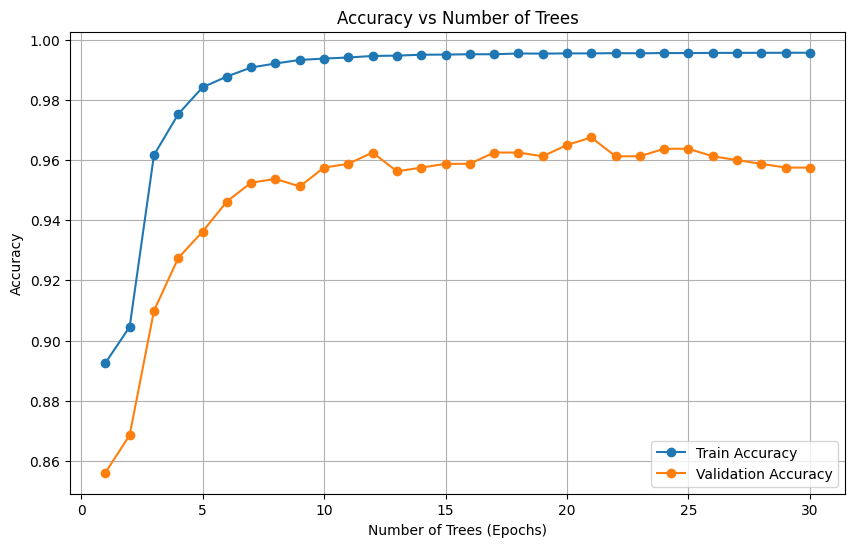

In [69]:
draw_story(train_accuracies ,val_accuracies)

In [70]:
test_metrics(X_test_bow ,y_test ,RFmodel)

Accuracy: 0.985
Precision: 0.9853703703703703
Recall: 0.985
F1-Score: 0.9850081327260898


# Now let's try to use Word2Vec.

###We will also add lemmatization.

In [50]:
!pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 12.1 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.14.1
    Uninstalling scipy-1.14.1:
      Successfully uninstalled scipy-1.14.1


In [51]:
import gensim
from gensim.models import Word2Vec
from nltk import sent_tokenize
from gensim.utils import simple_preprocess

In [87]:
story_train =  [word_tokenize(comment) for comment in train['comments']]
story_valid =  [word_tokenize(comment) for comment in valid['comments']]

W2Vmodel = Word2Vec(window=20, min_count=2, workers=4 , epochs=30)

W2Vmodel.build_vocab(story_train)
W2Vmodel.train(story_train, total_examples=W2Vmodel.corpus_count, epochs=W2Vmodel.epochs)

(22182591, 23262990)

In [88]:
def comment_vector(model, comment):
    tokens = [token for token in comment if token in model.wv]
    if len(tokens) == 0:
        return np.zeros(model.vector_size)
    return np.mean(model.wv[tokens], axis=0)

In [89]:
X_train = np.array([comment_vector(W2Vmodel, comment) for comment in story_train])
X_valid = np.array([comment_vector(W2Vmodel, comment) for comment in story_valid])

y_train = train['sentiment'].values
y_valid = valid['sentiment'].values

X_valid , X_test, y_valid , y_test = train_test_split(X_valid, y_valid, test_size = 0.2 , random_state= 42)

In [90]:
train_accuracies , val_accuracies , RFmodel = create_train_model(X_train, X_valid, y_train, y_valid, num_trees=30)

Epoch 1/30 - Train Accuracy: 0.8023, Val Accuracy: 0.6896
Epoch 2/30 - Train Accuracy: 0.8014, Val Accuracy: 0.6884
Epoch 3/30 - Train Accuracy: 0.9081, Val Accuracy: 0.7772
Epoch 4/30 - Train Accuracy: 0.9378, Val Accuracy: 0.8060
Epoch 5/30 - Train Accuracy: 0.9582, Val Accuracy: 0.8310
Epoch 6/30 - Train Accuracy: 0.9702, Val Accuracy: 0.8423
Epoch 7/30 - Train Accuracy: 0.9786, Val Accuracy: 0.8536
Epoch 8/30 - Train Accuracy: 0.9835, Val Accuracy: 0.8511
Epoch 9/30 - Train Accuracy: 0.9873, Val Accuracy: 0.8423
Epoch 10/30 - Train Accuracy: 0.9896, Val Accuracy: 0.8511
Epoch 11/30 - Train Accuracy: 0.9911, Val Accuracy: 0.8598
Epoch 12/30 - Train Accuracy: 0.9921, Val Accuracy: 0.8648
Epoch 13/30 - Train Accuracy: 0.9929, Val Accuracy: 0.8748
Epoch 14/30 - Train Accuracy: 0.9936, Val Accuracy: 0.8698
Epoch 15/30 - Train Accuracy: 0.9938, Val Accuracy: 0.8723
Epoch 16/30 - Train Accuracy: 0.9940, Val Accuracy: 0.8761
Epoch 17/30 - Train Accuracy: 0.9942, Val Accuracy: 0.8723
Epoch 

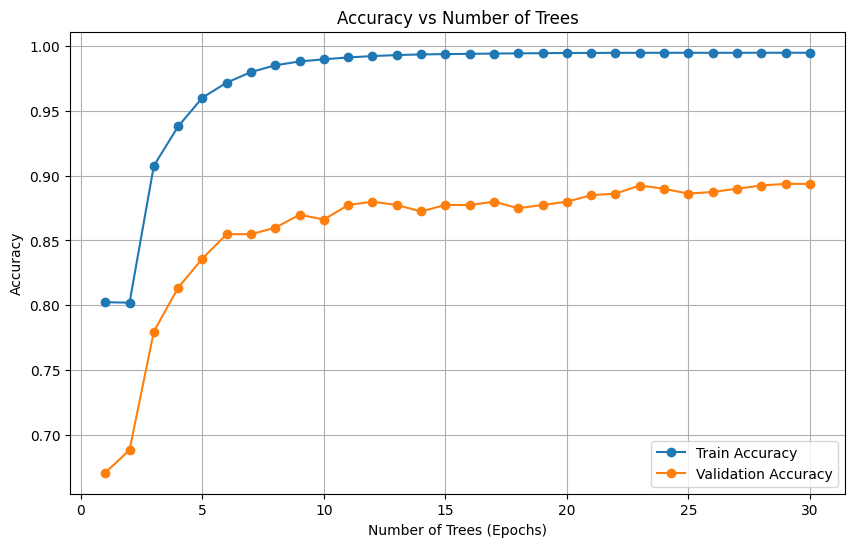

In [85]:
draw_story(train_accuracies ,val_accuracies)

In [91]:
test_metrics(X_test ,y_test ,RFmodel)

Accuracy: 0.875
Precision: 0.8753127466707405
Recall: 0.875
F1-Score: 0.8736270907867236
